In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('../data/Mall_Customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


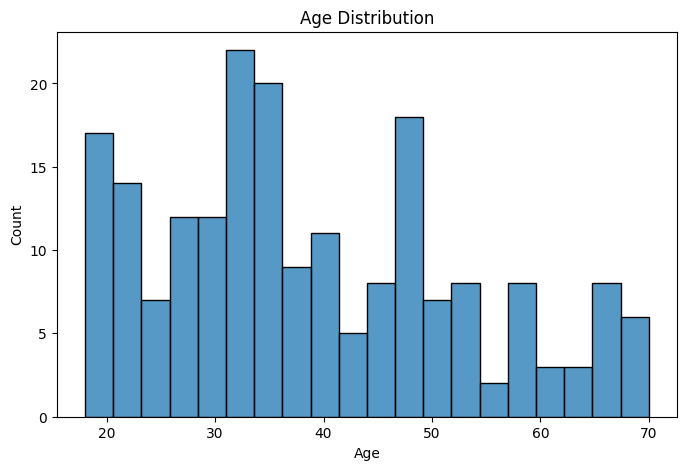

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title('Age Distribution')

plt.show()

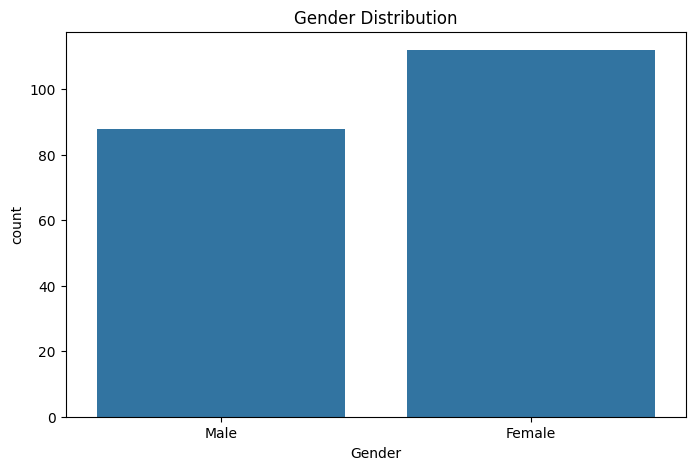

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

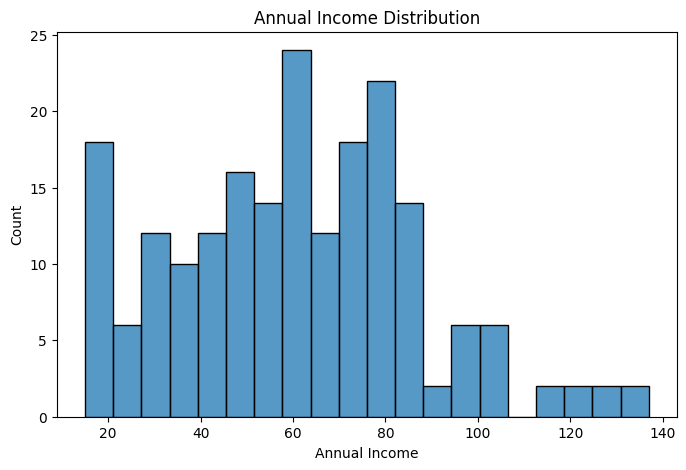

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20)

plt.title('Annual Income Distribution')

plt.xlabel('Annual Income')

plt.show()

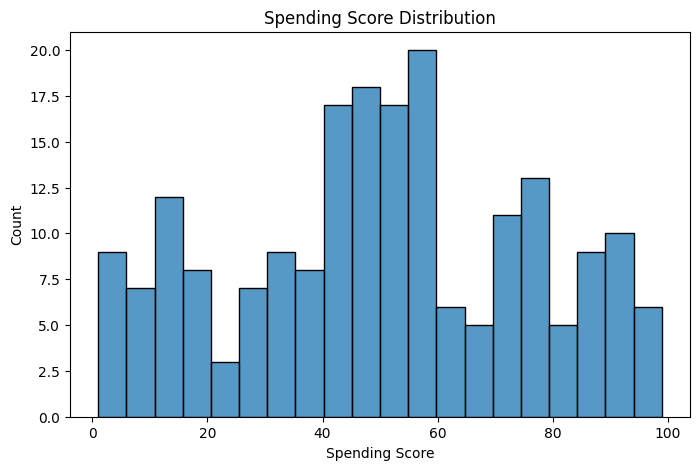

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20)

plt.title('Spending Score Distribution')

plt.xlabel('Spending Score')

plt.show()

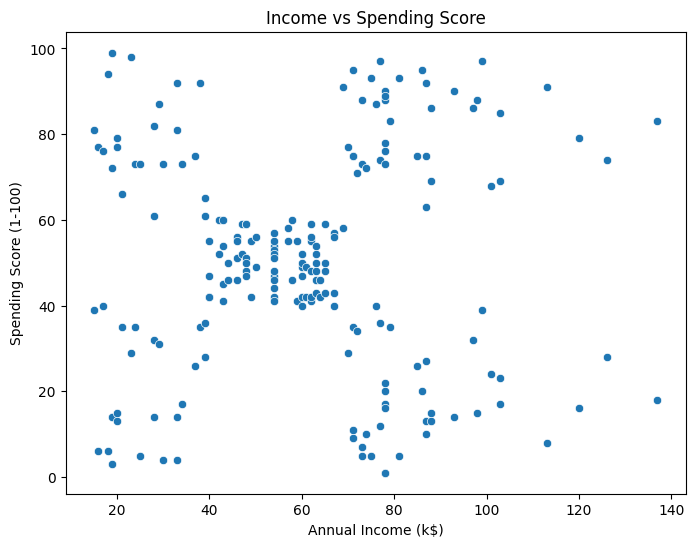

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Income vs Spending Score')

plt.show()

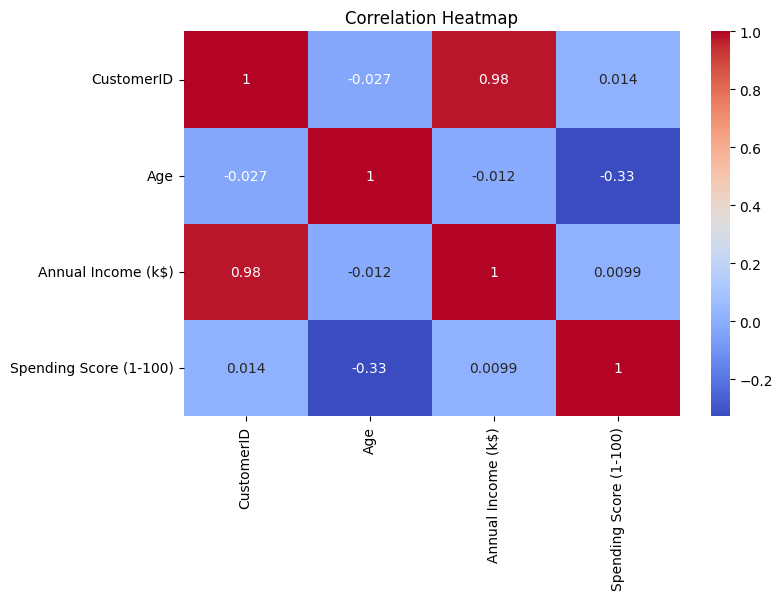

In [12]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    wcss.append(kmeans.inertia_)

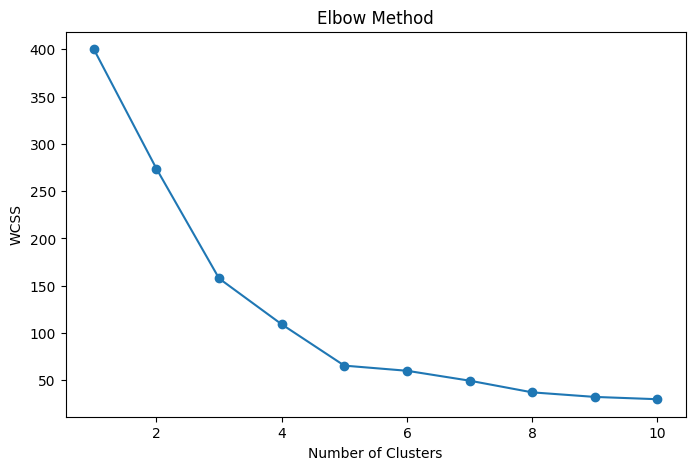

In [16]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [18]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


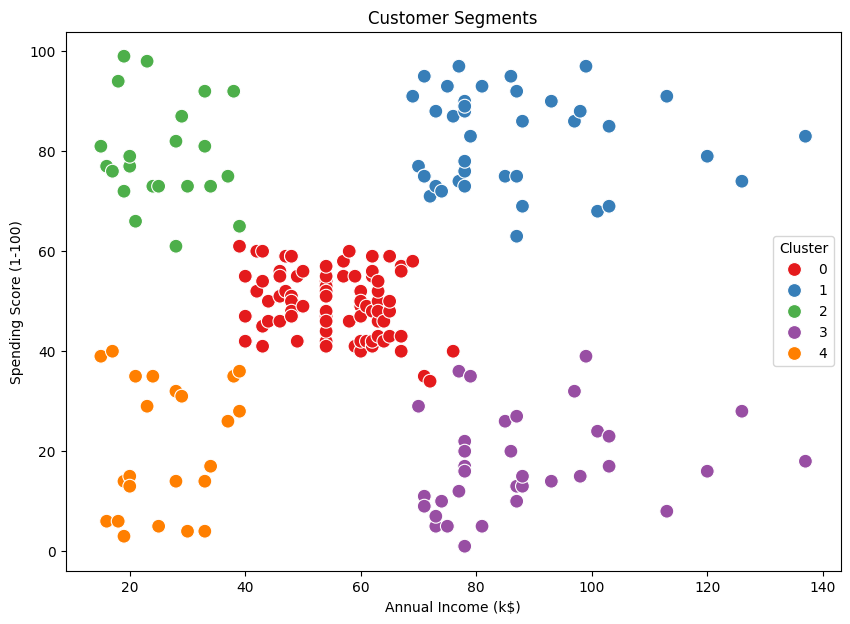

In [19]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title('Customer Segments')

plt.show()

In [20]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=[
        'Annual Income',
        'Spending Score'
    ]
)

centers_df

,Annual Income,Spending Score
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


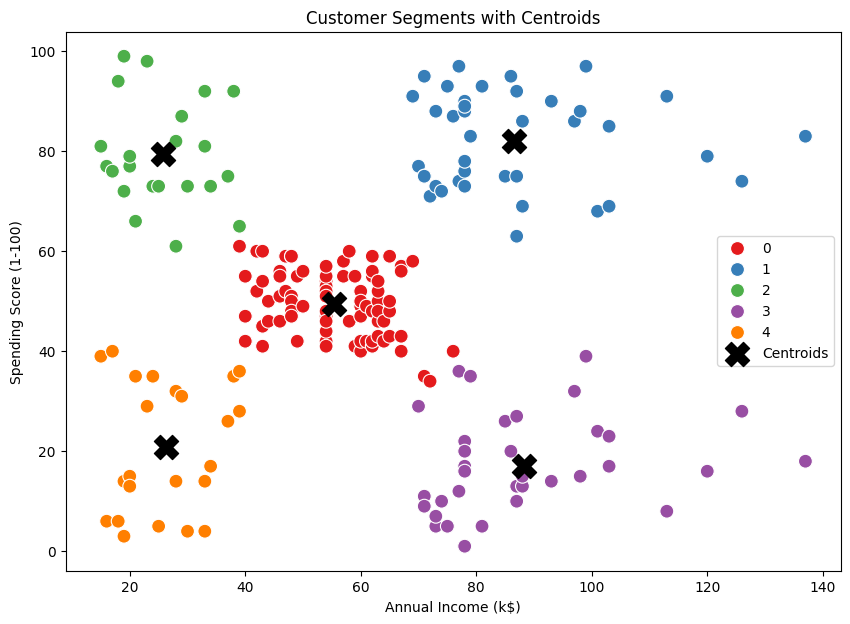

In [21]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    s=300,
    c='black',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments with Centroids')

plt.legend()

plt.show()

In [22]:
df.to_csv('../data/customer_segments.csv', index=False)

In [23]:
cluster_names = {
    0: 'Standard Customers',
    1: 'Premium Customers',
    2: 'Budget Customers',
    3: 'High Spenders',
    4: 'Careful Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

In [24]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,4,Careful Customers
1,2,Male,21,15,81,2,Budget Customers
2,3,Female,20,16,6,4,Careful Customers
3,4,Female,23,16,77,2,Budget Customers
4,5,Female,31,17,40,4,Careful Customers


In [25]:
df.to_csv('../data/customer_segments.csv', index=False)